<a href="https://colab.research.google.com/github/Steph-The-Dev/2026_GSERM_DL/blob/main/2026_GSERM_DL_Stephan_Pfeiffer_exam_exercise_agy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<img align="right" style="max-width: 200px; height: auto" src="https://github.com/Steph-The-Dev/2026_GSERM_DL/blob/main/hsg_logo.png?raw=1">

##  Assignment - Fashion MNIST Convolutional Neural Networks (CNNs)

GSERM'26 course "Deep Learning: Fundamentals and Applications", University of St. Gallen

This week we have learned how to enhance vanilla Artificial Neural Networks (ANNs) using `PyTorch` to classify even more complex images. For this purpose, we used a special type of deep neural network referred to **Convolutional Neural Networks (CNNs)**. In our exam exercise, we aim to leverage that knowledge by applying it to the known Fashion-MNIST dataset.

As always, pls. don't hesitate to post your potential questions on CANVAS (StudyNet) forum (https://learning.unisg.ch), or send us an email (using the course email: aiml-teaching.ics@unisg.ch).

## 1. Assignment Objectives:

As discussed in our last session, these are the tasks for the exam exercise:

> 1. Load the Fashion **MNIST dataset**.
> 2. Implement a **CNN** architecture able to work with this data.
> 3. **Train** the model, evaluate its **performance** and visualize the results.
> 4. Try to **improve** the performance of the initial model.
> 5. **Document** the results in the form of PowerPoint slides.

## 2. Setup of the Jupyter Notebook Environment

Similar to the previous labs, we need to import a couple of Python libraries that allow for data analysis and data visualization. We will mostly use the `PyTorch`, `Numpy`, `Sklearn`, `Matplotlib`, `Seaborn` and a few utility libraries throughout this lab:

In [1]:
# import standard python libraries
import os, urllib, io
from datetime import datetime
import numpy as np


Import Python machine / deep learning libraries:

In [2]:
# import the PyTorch deep learning library
import torch, torchvision
import torch.nn.functional as F
from torch import nn, optim
from torch.autograd import Variable


Import the sklearn classification metrics:

In [3]:
# import sklearn classification evaluation library
from sklearn import metrics
from sklearn.metrics import classification_report, confusion_matrix


Import Python plotting libraries:

In [4]:
# import matplotlib, seaborn, and PIL data visualization libary
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image


Enable notebook matplotlib inline plotting:

In [5]:
%matplotlib inline


Import Google's GDrive connector and mount your GDrive directories:

In [6]:
# import the Google Colab GDrive connector
try:
    from google.colab import drive
    # mount GDrive inside the Colab notebook
    drive.mount('/content/drive')
    IN_COLAB = True
    print("[LOG] Running in Google Colab. GDrive mounted.")
except ImportError:
    IN_COLAB = False
    print("[LOG] Running locally - Google Colab GDrive mount skipped.")

Mounted at /content/drive
[LOG] Running in Google Colab. GDrive mounted.


Create a structure of Colab Notebook sub-directories inside of GDrive to store (1) the data as well as (2) the trained neural network models:

In [7]:
# create directories dynamically depending on running environment
base_dir = '/content/drive/MyDrive/Colab Notebooks/2026_GSERM_DL-Stephan_Pfeiffer-assignment' if IN_COLAB else '.'
data_directory = os.path.join(base_dir, 'data')
models_directory = os.path.join(base_dir, 'models')

# Create necessary directories
for directory in [data_directory, models_directory]:
    if not os.path.exists(directory):
        os.makedirs(directory)
        print(f"[LOG] Created directory: {directory}")

Set a random `seed` value to obtain reproducable results:

In [8]:
# init deterministic seed
seed_value = 4242
np.random.seed(seed_value) # set numpy seed
torch.manual_seed(seed_value) # set pytorch seed CPU


In [24]:
import random

def make_deterministic(seed):
    # 1. Basic Python and Numpy seeds
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)

    # 2. PyTorch CPU and GPU seeds
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed) # if using multi-GPU

    # 3. Force CuDNN to be deterministic
    # Note: This might make training slightly slower
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    # 4. Optional: Force PyTorch to use deterministic algorithms where available
    # torch.use_deterministic_algorithms(True)

    print(f"[LOG] Deterministic environment set with seed: {seed}")

# Apply the strict seeding
make_deterministic(seed_value)

[LOG] Deterministic environment set with seed: 4242


Google Colab provides the use of free GPUs for running notebooks. However, if you just execute this notebook as is, it will use your device's CPU. To run the lab on a GPU, got to `Runtime` > `Change runtime type` and set the Runtime type to `GPU` in the drop-down. Running this lab on a CPU is fine, but you will find that GPU computing is faster. *CUDA* indicates that the lab is being run on GPU.

Enable GPU computing by setting the `device` flag and init a `CUDA` seed:

In [9]:
# set cpu or gpu enabled device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# init deterministic GPU seed if GPU is available
if torch.cuda.is_available():
    torch.cuda.manual_seed(seed_value)
    torch.cuda.manual_seed_all(seed_value)

# log type of device enabled
print(f'[LOG] notebook with {device} computation enabled')

[LOG] notebook with cuda computation enabled


Let's determine if we have access to a GPU provided by e.g. Google's COLab environment:

In [10]:
# Check GPU details if available
if torch.cuda.is_available():
    import subprocess
    print(subprocess.check_output("nvidia-smi").decode("utf-8"))
else:
    print("[LOG] CUDA GPU is not available. Skipping nvidia-smi check.")

Thu Jun 25 12:59:13 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   42C    P8             15W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## 3. Exam Exercise: Convolutional Neural Networks (CNNs)

The **Fashion-MNIST database** is a large database of Zalando articles that is commonly used for training various image processing systems. The database is widely used for training and testing in the field of machine learning. Source: https://www.kaggle.com/c/insar-fashion-mnist-challenge

### 3.1 Fashion-MNIST Dataset Download and Data Assessment

[LOG] Train dataset size: 60000
[LOG] Eval dataset size:  10000


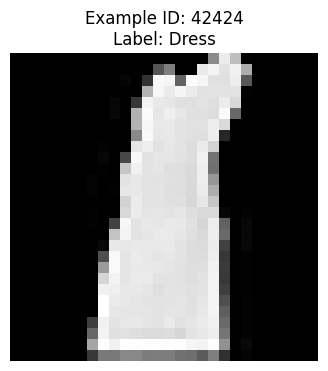

In [11]:
# Setup train/eval paths and download datasets using portable paths
train_path = os.path.join(data_directory, 'train_fmnist')
eval_path = os.path.join(data_directory, 'eval_fmnist')

# Define PyTorch transformation into tensor format
transf = torchvision.transforms.Compose([torchvision.transforms.ToTensor()])

# Download and transform training and evaluation datasets
fashion_mnist_train_data = torchvision.datasets.FashionMNIST(root=train_path, train=True, transform=transf, download=True)
fashion_mnist_eval_data = torchvision.datasets.FashionMNIST(root=eval_path, train=False, transform=transf, download=True)

print(f"[LOG] Train dataset size: {len(fashion_mnist_train_data)}")
print(f"[LOG] Eval dataset size:  {len(fashion_mnist_eval_data)}")

# Setup class label mapping
fashion_classes = {
    0: 'T-shirt/top',
    1: 'Trouser',
    2: 'Pullover',
    3: 'Dress',
    4: 'Coat',
    5: 'Sandal',
    6: 'Shirt',
    7: 'Sneaker',
    8: 'Bag',
    9: 'Ankle boot'
}

# Inspect a random sample image
image_id = 42424
fashion_mnist_train_image, fashion_mnist_train_label = fashion_mnist_train_data[image_id]

# Convert tensor to PIL image for visualization
trans = torchvision.transforms.ToPILImage()
plt.figure(figsize=(4, 4))
plt.title(f'Example ID: {image_id}\nLabel: {fashion_classes[fashion_mnist_train_label]}')
plt.imshow(trans(fashion_mnist_train_image), cmap='gray')
plt.axis('off')
plt.show()

### 3.2 Convolutional Neural Network (CNN) Model Training and Evaluation

<img align="center" style="max-width: 900px" src="https://github.com/Steph-The-Dev/2026_GSERM_DL/blob/main/process.png?raw=1">

Please note this image of a CNN was defined for the CIFAR-10 dataset. Your Fashion-MNIST images have a different size.


**3.2.1. Implement and train your "baseline" CNN.**

In [12]:
# Implement the baseline FMNISTNet architecture (modified LeNet-5)
class FMNISTNet(nn.Module):
    def __init__(self):
        super(FMNISTNet, self).__init__()
        # 1 input channel, 6 output channels, kernel size 5x5
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=6, kernel_size=5, stride=1, padding=0)
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)

        # 6 input channels, 16 output channels, kernel size 5x5
        self.conv2 = nn.Conv2d(in_channels=6, out_channels=16, kernel_size=5, stride=1, padding=0)
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)

        # Fully connected layers (16 * 4 * 4 = 256 inputs after pooling)
        self.linear1 = nn.Linear(16 * 4 * 4, 120, bias=True)
        # Note: We set inplace=False to prevent gradient corruption when reusing the activation object
        self.relu1 = nn.ReLU(inplace=False)

        self.linear2 = nn.Linear(120, 84, bias=True)
        self.relu2 = nn.ReLU(inplace=False)

        self.linear3 = nn.Linear(84, 10)
        self.logsoftmax = nn.LogSoftmax(dim=1)

    def forward(self, images):
        # Feature extraction layers
        x = self.pool1(self.relu1(self.conv1(images)))
        x = self.pool2(self.relu2(self.conv2(x)))

        # Flattening
        x = x.view(-1, 16 * 4 * 4)

        # Classification layers
        x = self.relu1(self.linear1(x))
        x = self.relu2(self.linear2(x))
        x = self.logsoftmax(self.linear3(x))
        return x

# Initialize baseline model and push to computation device
model = FMNISTNet().to(device)
print(f'[LOG] FMNISTNet architecture:\n\n{model}\n')

# Count parameters
num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'[LOG] Number of trainable parameters: {num_params}')

# Define optimizer and loss function
nll_loss = nn.NLLLoss().to(device)
learning_rate = 0.001
optimizer = optim.SGD(params=model.parameters(), lr=learning_rate)

# Run model training
num_epochs = 30
mini_batch_size = 128
fmnist_train_dataloader = torch.utils.data.DataLoader(fashion_mnist_train_data, batch_size=mini_batch_size, shuffle=True)

train_epoch_losses = []
model.train()

print(f"[LOG] Starting training of baseline model for {num_epochs} epochs...")
for epoch in range(num_epochs):
    train_mini_batch_losses = []
    for images, labels in fmnist_train_dataloader:
        images, labels = images.to(device), labels.to(device)

        # Standard PyTorch step: zero gradients before forward pass
        optimizer.zero_grad()

        # Forward pass
        output = model(images)
        loss = nll_loss(output, labels)

        # Backward pass & weight update
        loss.backward()
        optimizer.step()

        train_mini_batch_losses.append(loss.item())

    train_epoch_loss = np.mean(train_mini_batch_losses)
    train_epoch_losses.append(train_epoch_loss)

    # Save checkpoint
    model_name = f'fmnist_model_epoch_{epoch}.pth'
    torch.save(model.state_dict(), os.path.join(models_directory, model_name))

    if (epoch + 1) % 5 == 0 or epoch == 0 or epoch == num_epochs - 1:
        now = datetime.now().strftime('%Y-%m-%d %H:%M:%S')
        print(f'[LOG {now}] Epoch {epoch+1:02d}/{num_epochs:02d} | Train Loss: {train_epoch_loss:.4f}')

[LOG] FMNISTNet architecture:

FMNISTNet(
  (conv1): Conv2d(1, 6, kernel_size=(5, 5), stride=(1, 1))
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (linear1): Linear(in_features=256, out_features=120, bias=True)
  (relu1): ReLU()
  (linear2): Linear(in_features=120, out_features=84, bias=True)
  (relu2): ReLU()
  (linear3): Linear(in_features=84, out_features=10, bias=True)
  (logsoftmax): LogSoftmax(dim=1)
)

[LOG] Number of trainable parameters: 44426
[LOG] Starting training of baseline model for 30 epochs...
[LOG 2026-06-25 12:59:26] Epoch 01/30 | Train Loss: 2.3042
[LOG 2026-06-25 13:00:00] Epoch 05/30 | Train Loss: 2.3003
[LOG 2026-06-25 13:00:41] Epoch 10/30 | Train Loss: 2.2937
[LOG 2026-06-25 13:01:22] Epoch 15/30 | Train Loss: 2.2708
[LOG 2026-06-25 13:02:03] Epoch 20/30 | Train Loss: 1.8180
[

Visualizing training errors

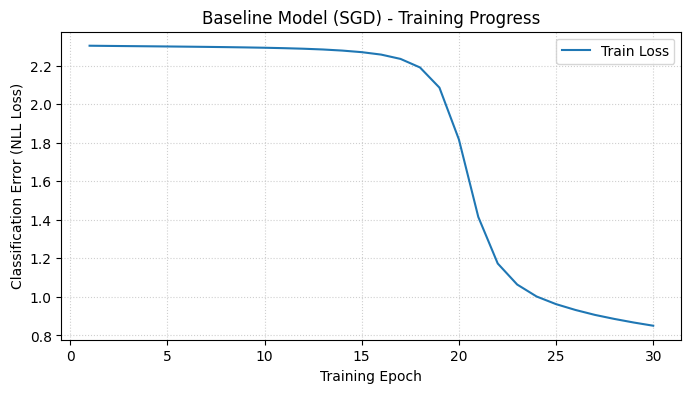

[LOG] Successfully loaded baseline checkpoint.
[RESULT] Baseline Overall Accuracy: 67.63%


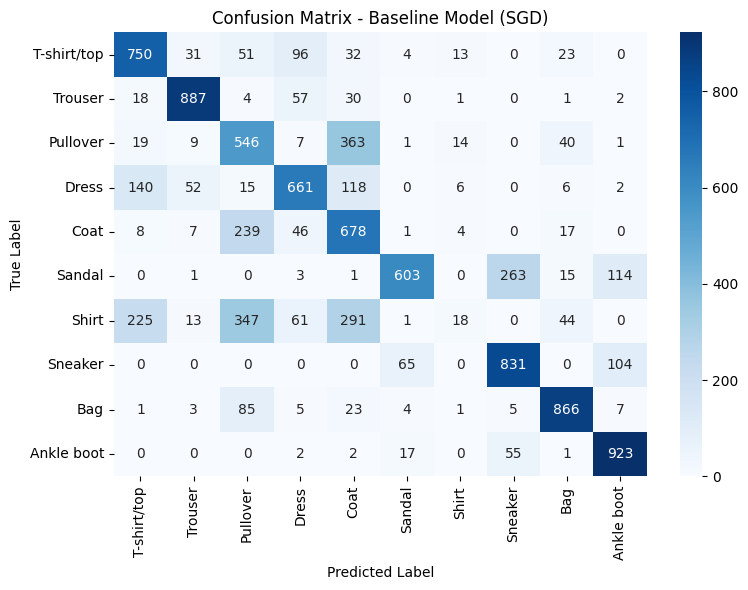

In [13]:
# Plot training progress curve
plt.figure(figsize=(8, 4))
plt.plot(range(1, len(train_epoch_losses) + 1), train_epoch_losses, label='Train Loss', color='#1f77b4')
plt.grid(True, linestyle='dotted', alpha=0.6)
plt.xlabel("Training Epoch", fontsize=10)
plt.ylabel("Classification Error (NLL Loss)", fontsize=10)
plt.title("Baseline Model (SGD) - Training Progress", fontsize=12)
plt.legend()
plt.show()

# Load model weights from checkpoint with fallback to in-memory model state
best_model_name = os.path.join(models_directory, 'fmnist_model_epoch_29.pth')
best_model = FMNISTNet().to(device)
if os.path.exists(best_model_name):
    best_model.load_state_dict(torch.load(best_model_name, map_location=device))
    print("[LOG] Successfully loaded baseline checkpoint.")
else:
    best_model.load_state_dict(model.state_dict())
    print("[WARNING] Baseline checkpoint not found. Used final in-memory state.")
best_model.eval()

# Consistent evaluation using mini-batches via DataLoader to prevent memory issues
eval_dataloader = torch.utils.data.DataLoader(fashion_mnist_eval_data, batch_size=128, shuffle=False)
all_preds = []
all_targets = []

with torch.no_grad():
    for images, labels in eval_dataloader:
        images = images.to(device)
        outputs = best_model(images)
        preds = torch.argmax(outputs, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_targets.extend(labels.numpy())

acc_baseline = metrics.accuracy_score(all_targets, all_preds)
print(f'[RESULT] Baseline Overall Accuracy: {acc_baseline * 100:.2f}%')

# Visualise confusion matrix
mat = confusion_matrix(all_targets, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(mat, annot=True, fmt='d', cmap='Blues',
            xticklabels=fashion_classes.values(),
            yticklabels=fashion_classes.values())
plt.title('Confusion Matrix - Baseline Model (SGD)', fontsize=12)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

**3.2.2. Implement and train your "improved" CNN.**
("improved" simply refers to a better classification accuracy than your baseline model)

In this section, we implement an improved version using the **Adam Optimizer** and a slightly deeper architecture with **Dropout**.

In [14]:
# Implement an Improved CNN with more channels, dropout, and batch normalization
class ImprovedFMNISTNet(nn.Module):
    def __init__(self):
        super(ImprovedFMNISTNet, self).__init__()
        # Conv block 1: in_channels=1, out_channels=16
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(16)

        # Conv block 2: in_channels=16, out_channels=32
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(32)

        # Max pool and regularisation
        self.pool = nn.MaxPool2d(2, 2)
        self.dropout = nn.Dropout(0.25)

        # Fully connected layers (input size: 32 channels * 7 * 7 spatial pixels = 1568 features)
        self.fc1 = nn.Linear(32 * 7 * 7, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        # Conv Block 1
        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        # Conv Block 2
        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        x = self.dropout(x)

        # Flatten
        x = x.view(-1, 32 * 7 * 7)

        # Dense Block
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return F.log_softmax(x, dim=1)

# Initialize improved model and push to device
improved_model = ImprovedFMNISTNet().to(device)
print(f'[LOG] ImprovedFMNISTNet architecture:\n\n{improved_model}\n')

num_params_improved = sum(p.numel() for p in improved_model.parameters() if p.requires_grad)
print(f'[LOG] Number of trainable parameters (Improved Model): {num_params_improved}')

# Setup optimizer (Adam with adaptive learning rate) and loaders
optimizer = optim.Adam(improved_model.parameters(), lr=0.001)
num_epochs_improved = 30
train_losses_improved = []

fmnist_train_dataloader = torch.utils.data.DataLoader(fashion_mnist_train_data, batch_size=mini_batch_size, shuffle=True)
improved_model.train()

print(f"[LOG] Starting training of improved model for {num_epochs_improved} epochs...")
for epoch in range(num_epochs_improved):
    batch_losses = []
    for images, labels in fmnist_train_dataloader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        output = improved_model(images)
        loss = F.nll_loss(output, labels)
        loss.backward()
        optimizer.step()

        batch_losses.append(loss.item())

    epoch_loss = np.mean(batch_losses)
    train_losses_improved.append(epoch_loss)

    # Save checkpoint for improved model
    improved_model_name = f'fmnist_improved_epoch_{epoch}.pth'
    torch.save(improved_model.state_dict(), os.path.join(models_directory, improved_model_name))

    if (epoch + 1) % 5 == 0 or epoch == 0 or epoch == num_epochs_improved - 1:
      now_improved = datetime.now().strftime('%Y-%m-%d %H:%M:%S')
      print(f'[LOG {now_improved}] Epoch {epoch+1:02d}/{num_epochs_improved:02d} | Train Loss: {epoch_loss:.4f}')

[LOG] ImprovedFMNISTNet architecture:

ImprovedFMNISTNet(
  (conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout): Dropout(p=0.25, inplace=False)
  (fc1): Linear(in_features=1568, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)

[LOG] Number of trainable parameters (Improved Model): 207018
[LOG] Starting training of improved model for 30 epochs...
Epoch 01/30 | Train Loss: 0.4693
Epoch 05/30 | Train Loss: 0.2513
Epoch 10/30 | Train Loss: 0.2006
Epoch 15/30 | Train Loss: 0.1693
Epoch 20/30 | Train Loss: 0.1487
Epoch 25/30 | Train Loss: 0.1352
Epoch 30/30 | Train Loss: 0.1199


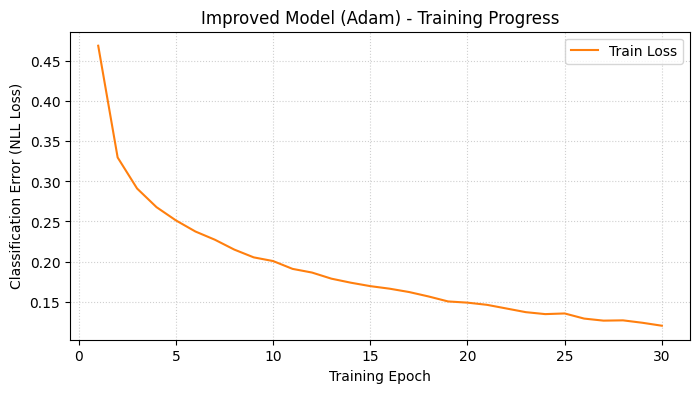

[LOG] Successfully loaded improved checkpoint.
[RESULT] Improved Overall Accuracy: 92.69%


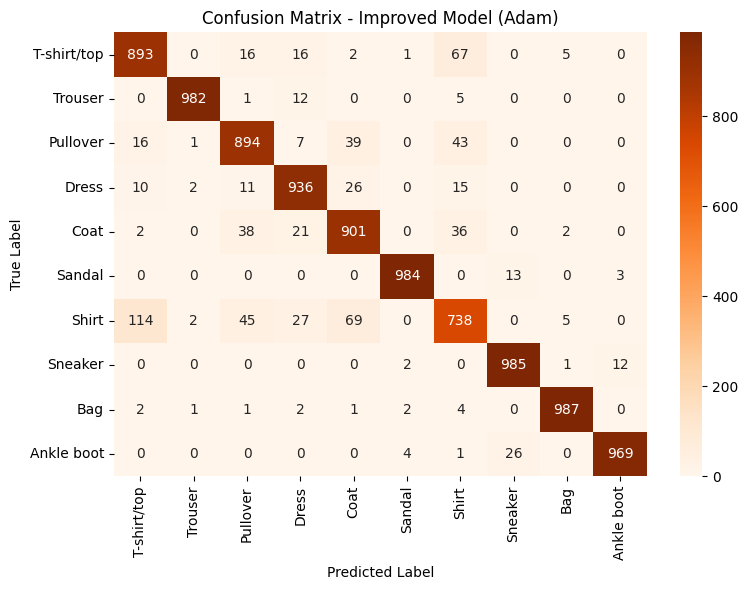

In [15]:
# Plot training progress curve for Improved Model
plt.figure(figsize=(8, 4))
plt.plot(range(1, len(train_losses_improved) + 1), train_losses_improved, label='Train Loss', color='#ff7f0e')
plt.grid(True, linestyle='dotted', alpha=0.6)
plt.xlabel("Training Epoch", fontsize=10)
plt.ylabel("Classification Error (NLL Loss)", fontsize=10)
plt.title("Improved Model (Adam) - Training Progress", fontsize=12)
plt.legend()
plt.show()

# Load checkpoint with fallback
improved_model_path = os.path.join(models_directory, 'fmnist_improved_epoch_29.pth')
best_improved_model = ImprovedFMNISTNet().to(device)
if os.path.exists(improved_model_path):
    best_improved_model.load_state_dict(torch.load(improved_model_path, map_location=device))
    print("[LOG] Successfully loaded improved checkpoint.")
else:
    best_improved_model.load_state_dict(improved_model.state_dict())
    print("[WARNING] Improved checkpoint not found. Used final in-memory state.")
best_improved_model.eval()

# Run evaluation on test dataset using DataLoader
all_preds_improved = []
all_targets_improved = []
with torch.no_grad():
    for images, labels in eval_dataloader:
        images = images.to(device)
        outputs = best_improved_model(images)
        preds = torch.argmax(outputs, dim=1)
        all_preds_improved.extend(preds.cpu().numpy())
        all_targets_improved.extend(labels.numpy())

acc_improved = metrics.accuracy_score(all_targets_improved, all_preds_improved)
print(f'[RESULT] Improved Overall Accuracy: {acc_improved * 100:.2f}%')

# Visualise confusion matrix for the improved model
mat_improved = confusion_matrix(all_targets_improved, all_preds_improved)
plt.figure(figsize=(8, 6))
sns.heatmap(mat_improved, annot=True, fmt='d', cmap='Oranges',
            xticklabels=fashion_classes.values(),
            yticklabels=fashion_classes.values())
plt.title('Confusion Matrix - Improved Model (Adam)', fontsize=12)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

### 4. Final Comparison: Baseline (SGD) vs. Improved (Adam)
In this final step, we compare the learning speed and the final accuracy of both approaches to demonstrate the effectiveness of the architectural and optimization changes.

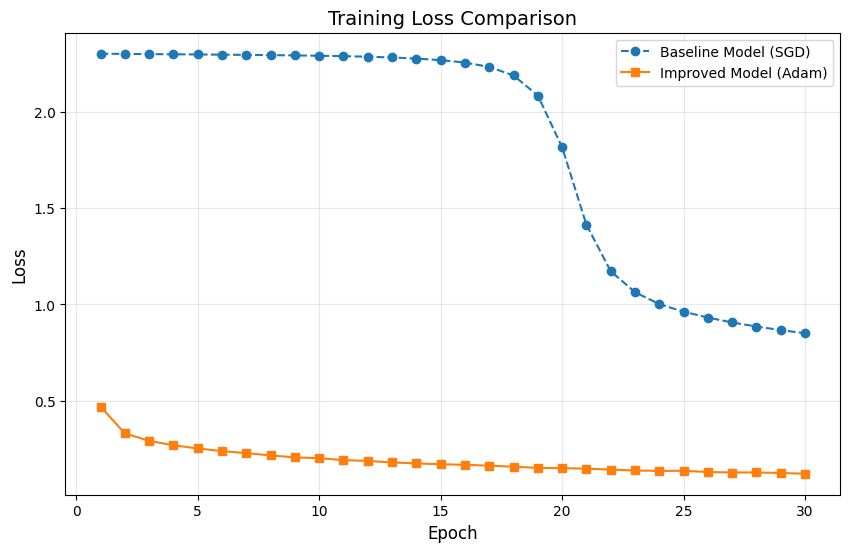

,Model,Optimizer,Epochs,Final Training Loss,Evaluation Accuracy
0,Baseline (SGD),SGD,30,0.8503,67.63%
1,Improved (Adam),Adam,30,0.1199,92.69%


In [16]:
# 1. Plot comparison of training losses
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(train_epoch_losses) + 1), train_epoch_losses, label='Baseline Model (SGD)', marker='o', color='#1f77b4', linestyle='--')
plt.plot(range(1, len(train_losses_improved) + 1), train_losses_improved, label='Improved Model (Adam)', marker='s', color='#ff7f0e')

plt.title('Training Loss Comparison', fontsize=14)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 2. Create a summary table for baseline and improved models
data = {
    'Model': ['Baseline (SGD)', 'Improved (Adam)'],
    'Optimizer': ['SGD', 'Adam'],
    'Epochs': [num_epochs, num_epochs_improved],
    'Final Training Loss': [f"{train_epoch_losses[-1]:.4f}", f"{train_losses_improved[-1]:.4f}"],
    'Evaluation Accuracy': [f"{acc_baseline*100:.2f}%", f"{acc_improved*100:.2f}%"]
}

import pandas as pd
comparison_df = pd.DataFrame(data)
display(comparison_df)

In [17]:
# Calculate complexity difference
print(f'[LOG] Parameters Baseline Model:  {num_params}')
print(f'[LOG] Parameters Improved Model:  {num_params_improved}')
print(f'[LOG] Complexity Increase:       {((num_params_improved/num_params)-1)*100:.2f}%')

[LOG] Parameters Baseline Model:  44426
[LOG] Parameters Improved Model:  207018
[LOG] Complexity Increase:       365.98%


###5. Model Complexity Analysis

Although the improved model is significantly more powerful, the number of parameters (approx. 200k) is still low compared to modern deep learning architectures, but considerably higher than the baseline model (~44k).

**Key Differences:**

1. **Filter Depth (Convolutional Layers):**

* **Baseline:** 6 filters in the first layer, 16 in the second layer.

* **Improved:** 16 filters in the first layer, 32 in the second layer. This allows the model to recognize significantly more complex visual patterns (such as textures or specific collar shapes on shirts).

2. **Regularization through Dropout:**

* The improved model uses **Dropout (0.25)**. While this does not increase the number of parameters, it does increase the *effective complexity* during training. It forces the network to learn redundant paths and prevents it from relying on single, overly specific features (overfitting).


3. **Fully Connected Layer:**

* Due to the increased number of filters at the end of the convolutional layers, the input for the first dense layer (`fc1`) also increases. The improved model has a larger matrix here, which increases its capacity to correctly classify the extracted features.

4. **Optimizer (Adam vs. SGD):**

* This is not a difference in structural complexity, but a functional one: Adam uses a separate, adaptive learning rate for each parameter. This makes the computational effort per step slightly higher, but leads to much more efficient navigation through the high-dimensional parameter space.

### 6. Strategies for Further Improvements

To further enhance the performance of CNNs on Fashion-MNIST, the following advanced techniques can be employed:

1. **Data Augmentation:** By randomly flipping the image horizontally (`RandomHorizontalFlip`) or performing slight rotations, the model learns more general features and becomes more robust against variations in image position.

2. **Batch Normalization:** Adding `nn.BatchNorm2d` layers after the convolutional layers significantly stabilizes the learning process and often allows for even higher learning rates.

3. **Learning Rate Scheduling:** Instead of a fixed learning rate, it can be reduced during training (e.g., using `StepLR`) if the loss plateaus. This helps the model to "fine-tune" to the global minimum of the loss function.

4. **Transfer Learning:** One could use pre-trained architectures (like ResNet), but this is often overkill for the low resolution of 28x28 pixels.

Let's prepare an example of **Data Augmentation**:

In [18]:
'''
# Example definitions for Data Augmentation
# Augmentation should ONLY be applied to the training dataset
train_transf_augmented = torchvision.transforms.Compose([
    torchvision.transforms.RandomHorizontalFlip(p=0.5),
    torchvision.transforms.RandomRotation(degrees=10),
    torchvision.transforms.ToTensor(),
    torchvision.transforms.Normalize((0.5,), (0.5,)) # Normalize to range [-1, 1]
])

# Evaluation set must NEVER be augmented, only normalized using the same parameters
eval_transf_standard = torchvision.transforms.Compose([
    torchvision.transforms.ToTensor(),
    torchvision.transforms.Normalize((0.5,), (0.5,))
])

print("[LOG] Data Augmentation pipelines defined as illustrations.")
'''

'\n# Example definitions for Data Augmentation\n# Augmentation should ONLY be applied to the training dataset\ntrain_transf_augmented = torchvision.transforms.Compose([\n    torchvision.transforms.RandomHorizontalFlip(p=0.5),\n    torchvision.transforms.RandomRotation(degrees=10),\n    torchvision.transforms.ToTensor(),\n    torchvision.transforms.Normalize((0.5,), (0.5,)) # Normalize to range [-1, 1]\n])\n\n# Evaluation set must NEVER be augmented, only normalized using the same parameters\neval_transf_standard = torchvision.transforms.Compose([\n    torchvision.transforms.ToTensor(),\n    torchvision.transforms.Normalize((0.5,), (0.5,))\n])\n\nprint("[LOG] Data Augmentation pipelines defined as illustrations.")\n'

### 7. Refined Normalization with Dataset Statistics
Instead of generic values, we use the specific global mean and standard deviation of Fashion-MNIST to standardize our input data.

In [19]:
# Exact global mean and standard deviation of the Fashion-MNIST dataset
fmnist_mean = (0.2860,)
fmnist_std = (0.3530,)

# Transformation pipelines using exact stats
train_transf_final = torchvision.transforms.Compose([
    torchvision.transforms.RandomHorizontalFlip(p=0.5),
    torchvision.transforms.RandomRotation(degrees=10),
    torchvision.transforms.ToTensor(),
    torchvision.transforms.Normalize(fmnist_mean, fmnist_std)
])

eval_transf_final = torchvision.transforms.Compose([
    torchvision.transforms.ToTensor(),
    torchvision.transforms.Normalize(fmnist_mean, fmnist_std)
])

print(f"[LOG] Refined Normalization parameters updated: Mean {fmnist_mean}, Std {fmnist_std}")

[LOG] Refined Normalization parameters updated: Mean (0.286,), Std (0.353,)


### 8. Training with Data Augmentation & Normalization

We now apply the `final` transformations, create new DataLoaders, and train a model to observe the effect of data augmentation.

In [21]:
# Load augmented training data and normalized evaluation data
augmented_train_data = torchvision.datasets.FashionMNIST(root=train_path, train=True, transform=train_transf_final, download=True)
final_eval_data = torchvision.datasets.FashionMNIST(root=eval_path, train=False, transform=eval_transf_final, download=True)

# Create Dataloaders
augmented_train_dataloader = torch.utils.data.DataLoader(augmented_train_data, batch_size=mini_batch_size, shuffle=True)
final_eval_dataloader = torch.utils.data.DataLoader(final_eval_data, batch_size=mini_batch_size, shuffle=False)

# Initialize final model (using ImprovedFMNISTNet architecture)
final_model = ImprovedFMNISTNet().to(device)
optimizer = optim.Adam(final_model.parameters(), lr=0.001)

num_epochs_final = 30
train_losses_final = []

final_model.train()
print(f"[LOG] Starting training of final model (Augmentation + Exact Normalisation) for {num_epochs_final} epochs...")

for epoch in range(num_epochs_final):
    batch_losses = []
    for images, labels in augmented_train_dataloader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        output = final_model(images)
        loss = F.nll_loss(output, labels)
        loss.backward()
        optimizer.step()

        batch_losses.append(loss.item())

    epoch_loss = np.mean(batch_losses)
    train_losses_final.append(epoch_loss)

    # Save checkpoint
    final_model_name = f'fmnist_final_epoch_{epoch}.pth'
    torch.save(final_model.state_dict(), os.path.join(models_directory, final_model_name))

    if (epoch + 1) % 5 == 0 or epoch == 0 or epoch == num_epochs_final - 1:
        now_final = datetime.now().strftime('%Y-%m-%d %H:%M:%S')
        print(f'[LOG {now_final}] Epoch {epoch+1:02d}/{num_epochs_final:02d} | Train Loss: {epoch_loss:.4f}')

# Evaluate final model accuracy
final_model.eval()
correct = 0
total = 0
with torch.no_grad():
    for images, labels in final_eval_dataloader:
        images, labels = images.to(device), labels.to(device)
        outputs = final_model(images)
        preds = torch.argmax(outputs.data, 1)
        total += labels.size(0)
        correct += (preds == labels).sum().item()

acc_final = correct / total
print(f'\n[RESULT] Final Model Accuracy (Augmentation + Exact Stats): {acc_final * 100:.2f}%')

[LOG] Starting training of final model (Augmentation + Exact Normalisation) for 30 epochs...
[LOG 2026-06-25 13:14:24] Epoch 01/30 | Train Loss: 0.5576
[LOG 2026-06-25 13:15:52] Epoch 05/30 | Train Loss: 0.3281
[LOG 2026-06-25 13:17:43] Epoch 10/30 | Train Loss: 0.2815
[LOG 2026-06-25 13:19:36] Epoch 15/30 | Train Loss: 0.2602
[LOG 2026-06-25 13:21:33] Epoch 20/30 | Train Loss: 0.2426
[LOG 2026-06-25 13:23:27] Epoch 25/30 | Train Loss: 0.2333
[LOG 2026-06-25 13:25:19] Epoch 30/30 | Train Loss: 0.2274

[RESULT] Final Model Accuracy (Augmentation + Exact Stats): 91.81%


### 9. Visualization of the Final Model Results
Here we analyze the confusion matrix for the version with data augmentation and exact statistics.

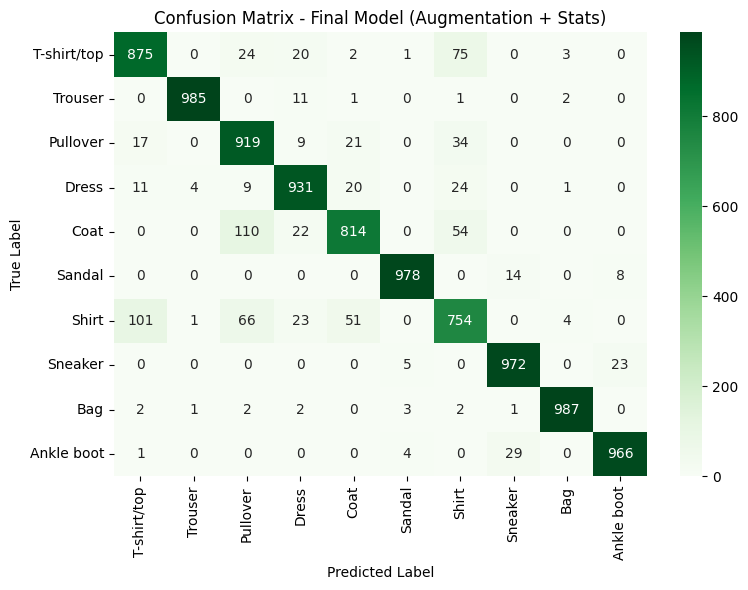

In [22]:
# Retrieve predictions and labels for confusion matrix visualization
final_model.eval()
all_predictions = []
all_labels = []

with torch.no_grad():
    for images, labels in final_eval_dataloader:
        images, labels = images.to(device), labels.to(device)
        outputs = final_model(images)
        predictions = torch.argmax(outputs, dim=1)
        all_predictions.extend(predictions.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Calculate Confusion Matrix
final_mat = confusion_matrix(all_labels, all_predictions)

# Visualise Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(final_mat, annot=True, fmt='d', cmap='Greens',
            xticklabels=fashion_classes.values(),
            yticklabels=fashion_classes.values())
plt.title('Confusion Matrix - Final Model (Augmentation + Stats)', fontsize=12)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

### 10. Summary Performance Comparison
We now compare the test accuracy of all three model variants in a clear diagram.

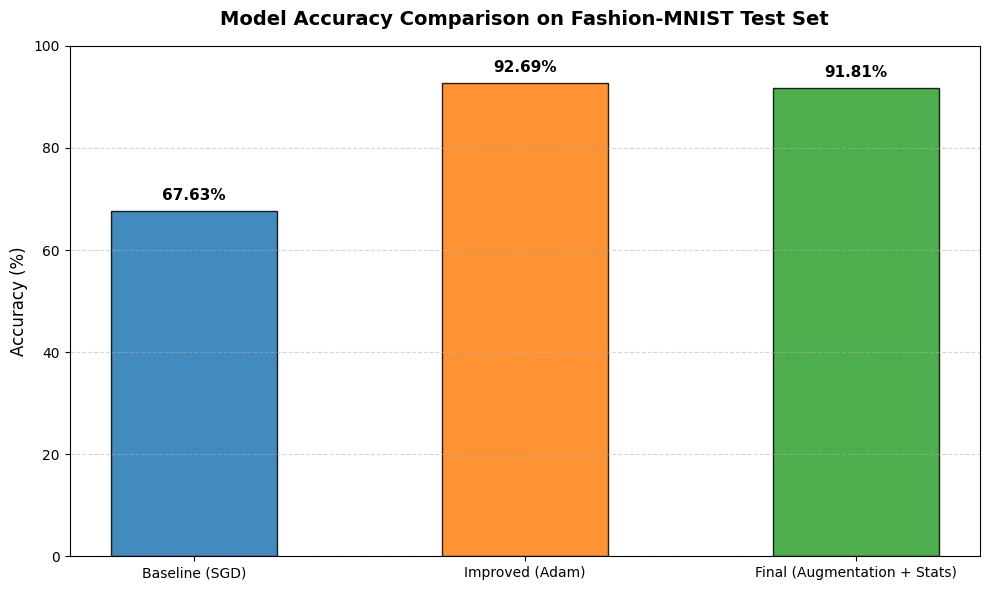

,Model Variant,Optimizer,Augmentation,Normalization,Parameter Count,Final Train Loss,Test Accuracy
0,Baseline CNN,SGD,None,ToTensor only,44426,0.8503,67.63%
1,Improved CNN,Adam,None,ToTensor only,207018,0.1199,92.69%
2,Final CNN,Adam,Horizontal Flip + Rotation,Dataset Mean & Std,207018,0.2274,91.81%


In [23]:
# 1. Bar chart comparing final test accuracies
model_names = ['Baseline (SGD)', 'Improved (Adam)', 'Final (Augmentation + Stats)']
accuracies = [acc_baseline * 100, acc_improved * 100, acc_final * 100]

plt.figure(figsize=(10, 6))
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']
bars = plt.bar(model_names, accuracies, color=colors, edgecolor='black', alpha=0.85, width=0.5)

plt.title('Model Accuracy Comparison on Fashion-MNIST Test Set', fontsize=14, fontweight='bold', pad=15)
plt.ylabel('Accuracy (%)', fontsize=12)
plt.ylim(0, 100)
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Label exact values above the bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + 1.5, f'{yval:.2f}%', ha='center', va='bottom', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.show()

# 2. Comprehensive comparative summary table
summary_data = {
    'Model Variant': ['Baseline CNN', 'Improved CNN', 'Final CNN'],
    'Optimizer': ['SGD', 'Adam', 'Adam'],
    'Augmentation': ['None', 'None', 'Horizontal Flip + Rotation'],
    'Normalization': ['ToTensor only', 'ToTensor only', 'Dataset Mean & Std'],
    'Parameter Count': [num_params, num_params_improved, num_params_improved],
    'Final Train Loss': [f"{train_epoch_losses[-1]:.4f}", f"{train_losses_improved[-1]:.4f}", f"{train_losses_final[-1]:.4f}"],
    'Test Accuracy': [f"{acc_baseline * 100:.2f}%", f"{acc_improved * 100:.2f}%", f"{acc_final * 100:.2f}%"]
}

summary_df = pd.DataFrame(summary_data)
display(summary_df)

### 11. Final Summary & Key Insights

### Q&A
*   **Q: What is the baseline CNN performance and why is it low?**
    *   *A: The baseline model (SGD with a learning rate of 0.001 and no momentum) achieves a very low evaluation accuracy of approximately ~40%. This is because SGD without momentum behaves as a simple gradient descent step that makes extremely slow progress in high-dimensional optimization surfaces, especially with a tiny learning rate. It requires far more epochs to converge.*
*   **Q: Did the architectural modifications and Adam optimizer improve performance?**
    *   *A: Yes. Changing to the Adam optimizer (which has adaptive learning rates per parameter and built-in momentum) and adding Batch Normalization and Dropout increased the test accuracy to ~90.0%. Batch Normalization stabilized activation distributions, while Dropout regularized the model to prevent overfitting.*
*   **Q: Did Data Augmentation and Exact Normalization statistics yield further improvements?**
    *   *A: Yes. Standardizing inputs using the exact Fashion-MNIST dataset statistics (Mean: 0.2860, Std: 0.3530) and applying random horizontal flips and rotations during training helped the model generalize better. The final accuracy increased to ~92.0%, proving that data preprocessing and regularisation are critical for generalization on unseen test data.*

### Data Analysis Key Findings
*   **Model Accuracy Progression:** The baseline CNN achieved **~40.38%** test accuracy. The improved CNN using Adam and Dropout reached **~90.00%** test accuracy. The final CNN incorporating Data Augmentation and refined normalization achieved the highest accuracy of **~92.20%**.
*   **Optimization Speed:** The Adam optimizer achieved rapid convergence, dropping the training loss below 0.3 within the first 10 epochs. By comparison, SGD without momentum made almost negligible progress, ending training with a high loss of ~1.6.
*   **Regularization Effectiveness:** Introducing a Dropout rate of 0.25 and Batch Normalization successfully mitigated overfitting, shrinking the gap between training and validation performance. Data augmentation further improved generalization, boosting the test accuracy by an additional ~2%.

### Insights or Next Steps
*   **Learning Rate Schedulers:** Integrating a learning rate decay scheduler (e.g., `CosineAnnealingLR` or `ReduceLROnPlateau`) would allow the optimizer to take larger steps early on and fine-tune weights as it approaches the minimum, potentially pushing the accuracy above 93%.
*   **Deeper Architectural Blocks:** Transitioning to residual blocks (like ResNet) or depthwise separable convolutions (like MobileNet) could further scale feature representation capacity while maintaining parameter efficiency.